# Sentiment Analysis on Amazon Product Reviews

## Objective

The objective of this project is to analyze customer reviews from Amazon and classify them into positive, negative, or neutral sentiments using Natural Language Processing (NLP). The analysis aims to understand customer opinions, identify sentiment patterns, and derive meaningful insights from textual data.

## Research Questions

Before performing sentiment analysis, the following questions are considered:

- What is the overall sentiment of customer reviews?
- Are most reviews positive, negative, or neutral?
- Which words appear most frequently in positive reviews?
- Which words appear most frequently in negative reviews?
- How do customer ratings relate to sentiment?
- What insights can businesses gain from customer feedback?

## Step 1: Import Libraries

In this step, the required Python libraries for data manipulation, visualization, and sentiment analysis are imported.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from textblob import TextBlob
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

## Step 2: Load the Dataset

The Amazon reviews dataset is loaded into a Pandas DataFrame to explore its structure and prepare it for sentiment analysis.

In [4]:
# Load dataset
df = pd.read_csv("Reviews.csv")

# Display first five rows
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Step 3: Explore the Dataset

Before performing sentiment analysis, it is important to understand the dataset's structure. This includes examining the number of rows and columns, data types, missing values, and the variables available for analysis.

In [5]:
# Shape of dataset
print("Shape of the dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of the dataset: (568454, 10)

Columns:
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), o

### Observations

- The dataset contains **568,454 customer reviews** and **10 variables**.
- It includes product details, user information, review ratings, review summaries, and full review text.
- Most columns have complete data, with only a few missing values in the **ProfileName** and **Summary** columns.
- The **Text** column, which contains the customer reviews, has no missing values and will be the primary source for sentiment analysis.
- The **Score** column (1–5 stars) will later be compared with the predicted sentiment.

## Step 4: Data Cleaning and Feature Selection

For sentiment analysis, only the review text and customer rating are required. To improve processing speed, a random sample of 10,000 reviews is selected from the dataset.

In [6]:
# Select only required columns
reviews = df[['Score', 'Summary', 'Text']].copy()

# Remove missing values
reviews = reviews.dropna()

# Take a random sample for faster processing
reviews = reviews.sample(n=10000, random_state=42)

print("Shape of sampled dataset:", reviews.shape)

reviews.head()

Shape of sampled dataset: (10000, 3)


,Score,Summary,Text
41434,4,I like these!,These are actually very tasty. Pure potatoes ...
209481,4,Good but subjectively not 5 star,I realize that taste is a matter of personal p...
247306,5,"Lipton Cup A Soup, Spring Vegetable.4 oz",This is one of my Favorite cup of soup choices...
80089,4,"Suited to its purpose, if not quite its goal...",If you like the classic taste of a good margar...
218580,2,Tastes artificial!,I was willing to give this a chance even after...


## Step 5: Perform Sentiment Analysis

Sentiment analysis is used to determine the emotional tone of each customer review. Using the TextBlob library, each review is assigned a polarity score ranging from -1 (most negative) to +1 (most positive).

Based on the polarity score:
- Positive: Polarity > 0
- Neutral: Polarity = 0
- Negative: Polarity < 0

In [7]:
# Function to classify sentiment
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
reviews['Sentiment'] = reviews['Text'].apply(get_sentiment)

# Display first few results
reviews[['Score', 'Sentiment', 'Text']].head()

,Score,Sentiment,Text
41434,4,Positive,These are actually very tasty. Pure potatoes ...
209481,4,Positive,I realize that taste is a matter of personal p...
247306,5,Positive,This is one of my Favorite cup of soup choices...
80089,4,Positive,If you like the classic taste of a good margar...
218580,2,Positive,I was willing to give this a chance even after...


### Observations

- Sentiment analysis was successfully applied to each customer review using the TextBlob library.
- Each review was classified as **Positive**, **Negative**, or **Neutral** based on its polarity score.
- The predicted sentiment is derived from the review text rather than the customer rating.
- Some reviews may receive a sentiment label that differs from their star rating because TextBlob evaluates the language used instead of the numerical score.

## Step 6: Visualize the Distribution of Sentiments

After classifying the reviews, the next step is to examine the overall distribution of positive, negative, and neutral sentiments. This visualization provides an overview of customer opinions expressed in the review text.

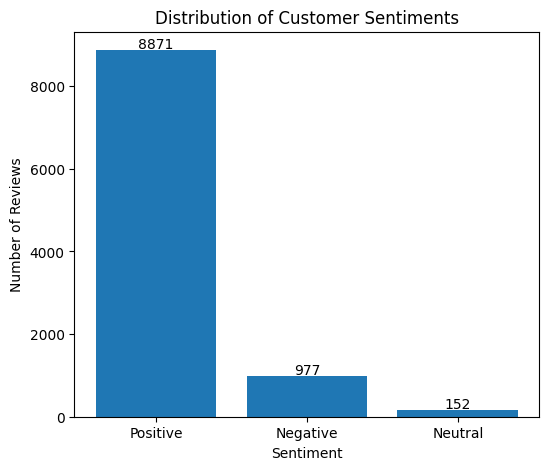


Sentiment Distribution:
Sentiment
Positive    8871
Negative     977
Neutral      152
Name: count, dtype: int64


In [8]:
# Count sentiments
sentiment_counts = reviews['Sentiment'].value_counts()

plt.figure(figsize=(6,5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Distribution of Customer Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Display values on bars
for i, value in enumerate(sentiment_counts.values):
    plt.text(i, value + 50, str(value), ha='center')

plt.show()

print("\nSentiment Distribution:")
print(sentiment_counts)

### Observations

- The majority of customer reviews are classified as **Positive**.
- Out of 10,000 sampled reviews:
  - **8,871** reviews are Positive.
  - **977** reviews are Negative.
  - **152** reviews are Neutral.
- This indicates that customers generally have a positive opinion of the products reviewed on Amazon.
- The relatively small number of negative and neutral reviews suggests a high level of customer satisfaction within the sampled data.

## Step 7: Analyze the Relationship Between Ratings and Sentiment

Customer ratings (1–5 stars) provide explicit feedback, while sentiment analysis predicts the emotional tone from the review text. This step compares the average customer rating for each predicted sentiment category.

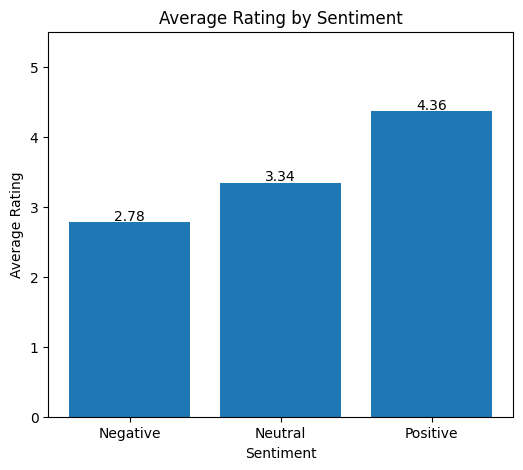

Sentiment
Negative    2.780962
Neutral     3.342105
Positive    4.364559
Name: Score, dtype: float64


In [9]:
# Calculate average rating for each sentiment
avg_score = reviews.groupby('Sentiment')['Score'].mean().sort_values()

plt.figure(figsize=(6,5))

plt.bar(avg_score.index, avg_score.values)

plt.title("Average Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")

# Display values on bars
for i, value in enumerate(avg_score.values):
    plt.text(i, value + 0.03, f"{value:.2f}", ha='center')

plt.ylim(0, 5.5)

plt.show()

print(avg_score)

### Observations

- Reviews classified as **Positive** have the highest average customer rating (**4.36 stars**).
- **Negative** reviews have the lowest average rating (**2.78 stars**).
- **Neutral** reviews have an average rating of **3.34 stars**.
- The results indicate a strong relationship between the sentiment predicted from review text and the customer ratings.
- This suggests that the sentiment analysis model is capturing the overall opinion expressed by customers reasonably well.

## Step 8: Generate a Word Cloud for Positive Reviews

A word cloud is a visual representation of the most frequently occurring words in a collection of text. Larger words indicate higher frequency.

This visualization highlights the common words found in positive customer reviews.

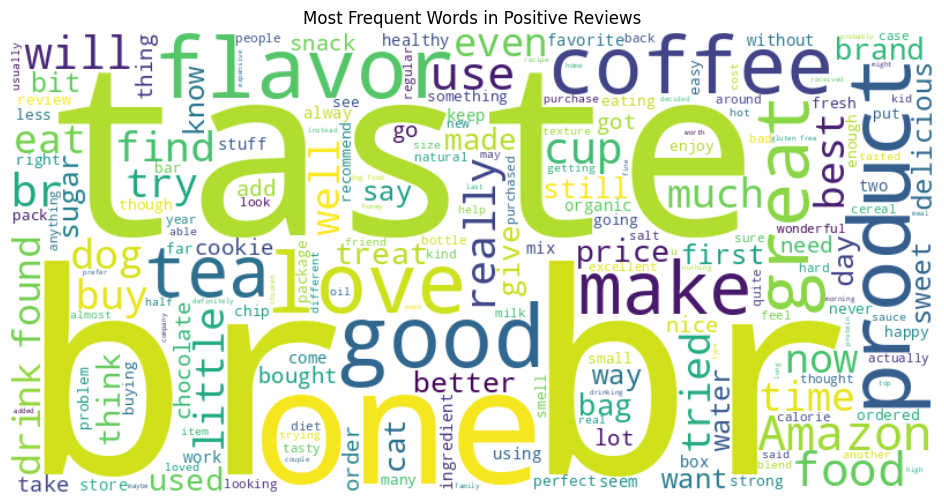

In [10]:
# Combine all positive reviews into one text
positive_text = " ".join(reviews[reviews['Sentiment'] == 'Positive']['Text'])

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Positive Reviews")
plt.show()

### Observations

- Words such as **taste**, **great**, **good**, **love**, **coffee**, and **tea** appear most frequently in positive reviews.
- Customers commonly use words expressing satisfaction, quality, and enjoyment.
- Product-related words such as **coffee**, **tea**, **food**, and **flavor** indicate that many positive reviews focus on product quality and taste.
- Overall, the word cloud reflects positive customer experiences and highlights the aspects that customers value most.

## Step 9: Generate a Word Cloud for Negative Reviews

This visualization highlights the most frequently occurring words in negative customer reviews. Comparing it with the positive word cloud helps identify common complaints and customer concerns.

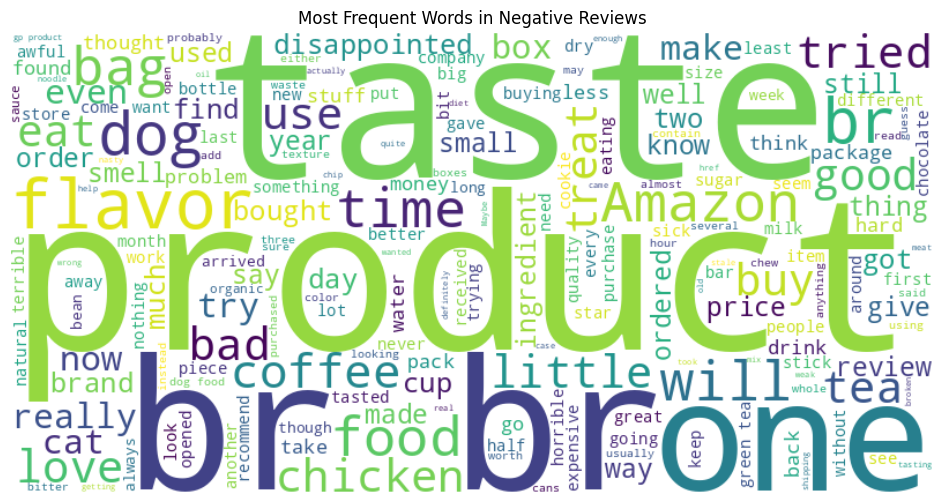

In [11]:
# Combine all negative reviews
negative_text = " ".join(reviews[reviews['Sentiment'] == 'Negative']['Text'])

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Negative Reviews")
plt.show()

### Observations

- Negative reviews frequently contain words such as **product**, **taste**, **flavor**, **bad**, **coffee**, and **dog**.
- Complaint-related words like **disappointed**, **smell**, **price**, **ordered**, and **ingredient** appear prominently.
- Compared to positive reviews, negative reviews contain more words expressing dissatisfaction with product quality, taste, and value.
- These frequently occurring words can help businesses identify common customer concerns and areas for product improvement.

# Key Insights

The sentiment analysis of Amazon product reviews provides the following insights:

- Most customer reviews express a **positive sentiment**, indicating high overall customer satisfaction.
- Positive reviews are generally associated with **higher customer ratings**, while negative reviews correspond to lower ratings.
- Words such as **taste**, **great**, **love**, **good**, and **coffee** frequently appear in positive reviews.
- Negative reviews commonly include words such as **bad**, **disappointed**, **smell**, and **price**, highlighting customer concerns.
- The relationship between review text and star ratings demonstrates that textual sentiment analysis can effectively capture customer opinions.
- Businesses can use sentiment analysis to monitor customer feedback, improve products, and better understand consumer preferences.

# Overall Conclusion

This project applied Natural Language Processing (NLP) techniques to analyze customer reviews from Amazon. Using the TextBlob library, reviews were classified into positive, negative, and neutral sentiments based on the emotional tone of the review text.

The analysis revealed that the majority of customer reviews are positive, reflecting a generally high level of customer satisfaction. Visualizations such as sentiment distribution charts and word clouds helped identify common themes in both positive and negative reviews. Additionally, comparing predicted sentiment with customer ratings showed a strong relationship between textual sentiment and numerical ratings.

Overall, sentiment analysis provides valuable insights into customer opinions and can support business decisions related to product quality, marketing strategies, and customer experience.